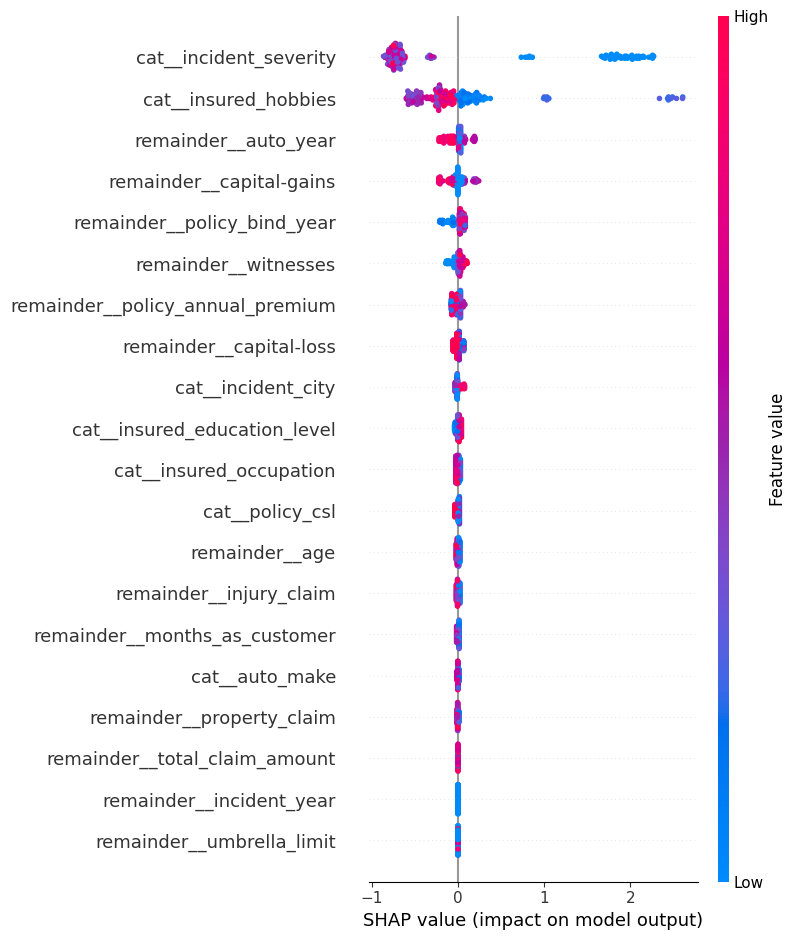

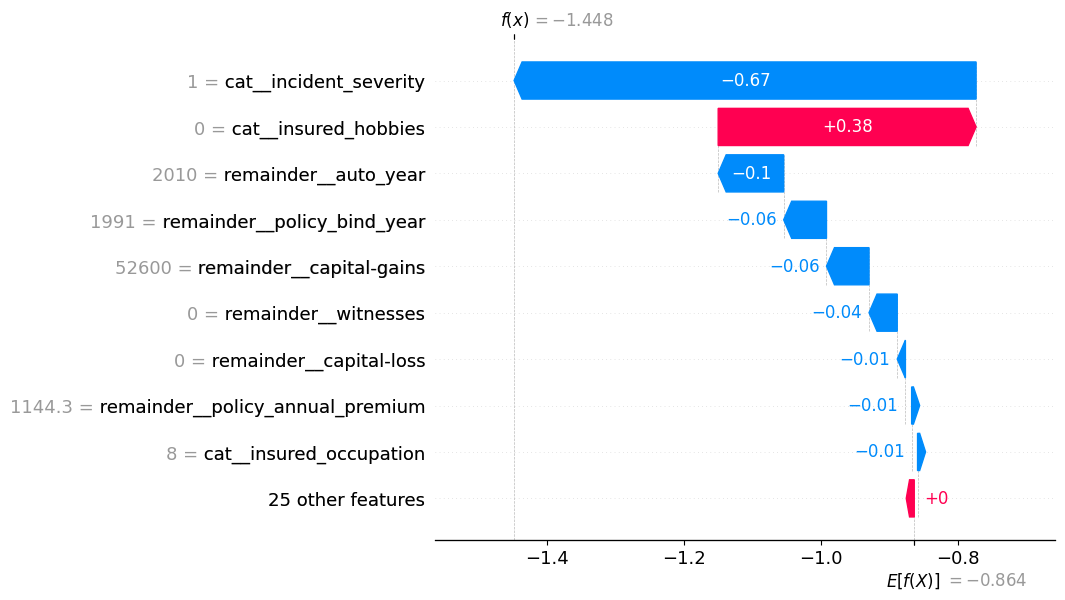

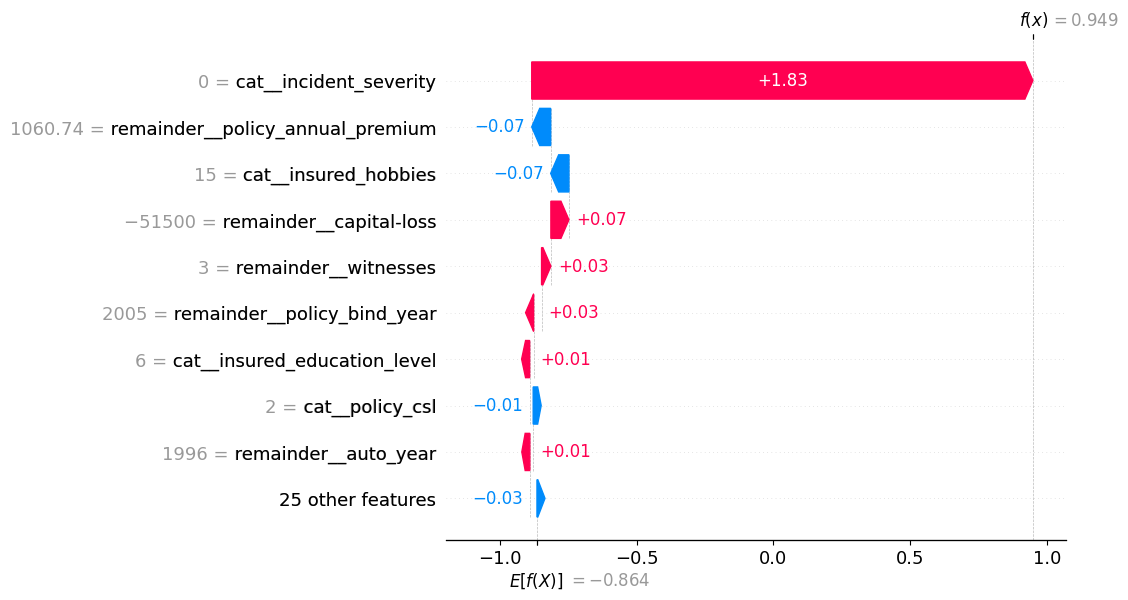

In [9]:
import shap
import joblib
import pandas as pd

X_train_processed = joblib.load('X_train_processed.pkl')
X_test_processed = joblib.load('X_test_processed.pkl')
y_train = joblib.load('y_train.pkl')
y_test = joblib.load('y_test.pkl')
best_model = joblib.load('best_model_lgb.pkl')
preprocessor = joblib.load('preprocessor.pkl')




feature_names = preprocessor.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_df)
shap.summary_plot(shap_values, X_test_df)

feature_names = [name.split('__')[1] for name in preprocessor.get_feature_names_out()]


shap.plots.waterfall(shap_values[0])


fraud_idx = list(y_test.reset_index(drop=True)[y_test.reset_index(drop=True) == 1].index)[0]
shap.plots.waterfall(shap_values[fraud_idx])
